In [ ]:
!pip install -q xgboost imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nClass Distribution:")
print(df["Class"].value_counts())

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


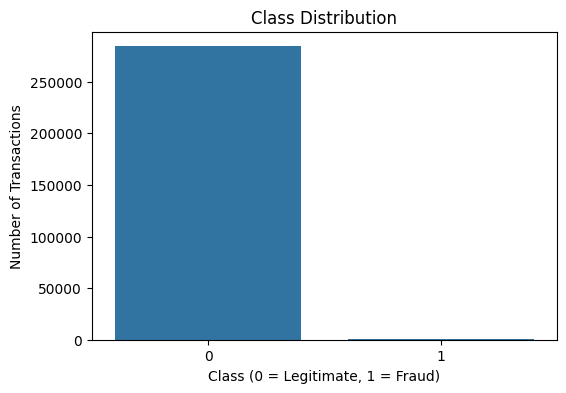


Class Distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

print("\nClass Distribution (%):")
print(df["Class"].value_counts(normalize=True) * 100)

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Set:", X_train.shape)
print("Testing Set :", X_test.shape)


Training Set: (227845, 30)
Testing Set : (56962, 30)


In [ ]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nClass Distribution Before SMOTE:")
print(y_train.value_counts())

print("\nClass Distribution After SMOTE:")
print(y_train_smote.value_counts())


Class Distribution Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Class Distribution After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_smote,
    y_train_smote
)

print("\nXGBoost model trained successfully.")


XGBoost model trained successfully.


In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\nSample predicted probabilities:")
print(y_prob[:10])


Sample predicted probabilities:
[1.54730616e-04 1.45606455e-05 1.07271386e-04 7.48598677e-06
 2.51990627e-03 1.88122154e-04 4.33777786e-05 7.81287599e-05
 4.31609486e-04 3.42092011e-04]


In [ ]:
y_pred_05 = (y_prob >= 0.5).astype(int)

print("\n--- Evaluation at Threshold = 0.5 ---")

print("Accuracy :", accuracy_score(y_test, y_pred_05))
print("Precision:", precision_score(y_test, y_pred_05))
print("Recall   :", recall_score(y_test, y_pred_05))
print("F1 Score :", f1_score(y_test, y_pred_05))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_05,
    target_names=["Legitimate", "Fraud"]
))


--- Evaluation at Threshold = 0.5 ---
Accuracy : 0.9983146659176293
Precision: 0.5058823529411764
Recall   : 0.8775510204081632
F1 Score : 0.6417910447761194
ROC-AUC  : 0.9782596212373526
PR-AUC   : 0.8663830431955917

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.51      0.88      0.64        98

    accuracy                           1.00     56962
   macro avg       0.75      0.94      0.82     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
thresholds = np.arange(0.05, 1.00, 0.05)

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test, y_pred, zero_division=0
    )

    recall = recall_score(
        y_test, y_pred, zero_division=0
    )

    f1 = f1_score(
        y_test, y_pred, zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])


threshold_results = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

print("\nThreshold Tuning Results:")
display(threshold_results)



Threshold Tuning Results:


,Threshold,Precision,Recall,F1 Score
0,0.05,0.082331,0.908163,0.150975
1,0.10,0.142400,0.908163,0.246196
2,0.15,0.202273,0.908163,0.330855
3,0.20,0.252874,0.897959,0.394619
4,0.25,0.312057,0.897959,0.463158
5,0.30,0.362140,0.897959,0.516129
6,0.35,0.396396,0.897959,0.550000
7,0.40,0.439394,0.887755,0.587838
8,0.45,0.483146,0.877551,0.623188
9,0.50,0.505882,0.877551,0.641791


In [ ]:
best_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold = best_row["Threshold"]

print("\nBest Threshold:", best_threshold)
print("Precision     :", best_row["Precision"])
print("Recall        :", best_row["Recall"])
print("F1 Score      :", best_row["F1 Score"])


Best Threshold: 0.9500000000000001
Precision     : 0.9186046511627907
Recall        : 0.8061224489795918
F1 Score      : 0.8586956521739131


In [ ]:
y_pred_final = (
    y_prob >= best_threshold
).astype(int)

print("\n--- Final Model Performance ---")

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))


--- Final Model Performance ---
Accuracy : 0.9995435553526912
Precision: 0.9186046511627907
Recall   : 0.8061224489795918
F1 Score : 0.8586956521739131
ROC-AUC  : 0.9782596212373526
PR-AUC   : 0.8663830431955917


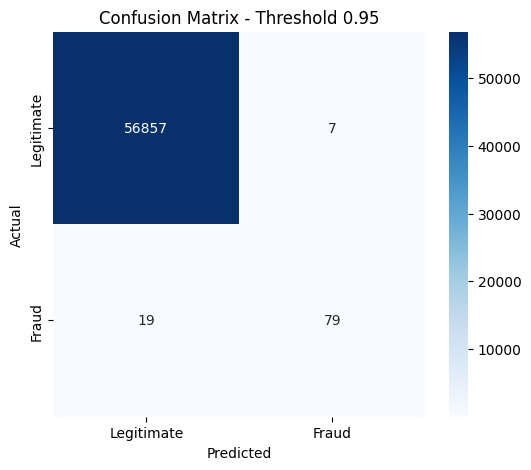

In [ ]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Confusion Matrix - Threshold {best_threshold:.2f}"
)

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Important Features:")
display(feature_importance.head(15))


Top 15 Important Features:


,Feature,Importance
14,V14,0.511810
10,V10,0.089608
4,V4,0.053231
12,V12,0.039152
8,V8,0.030201
13,V13,0.018499
26,V26,0.016237
18,V18,0.014920
1,V1,0.014723
0,Time,0.014480


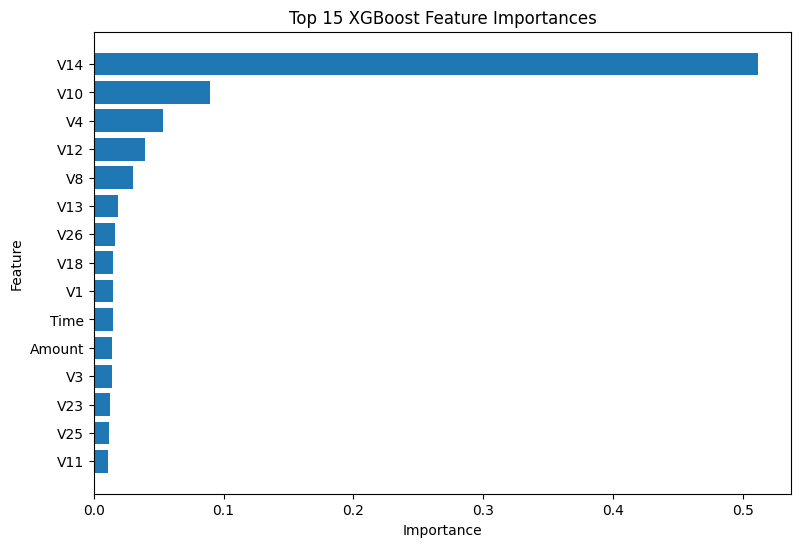

In [ ]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.show()